In [1]:
import uproot
import polars as pl
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

## Load the Simulated Data

In [2]:
root_file_path = "pixel_singles_a_local_j_0.root"
# 1. Scan for valid trees
with uproot.open(root_file_path) as root_file:
    valid_trees = [
        f"{root_file_path}:Pixel_{i}_Singles"
        for i in range(1, 81)
        if f"Pixel_{i}_Singles" in root_file
    ]

# 2. Read into Awkward Array using multithreading
# library="ak" is uproot's default and fastest backend
ak_array = uproot.concatenate(valid_trees, library="ak", num_workers=32)

# 3. Convert to Polars via PyArrow (zero-copy transfer)
arrow_table = ak.to_arrow_table(ak_array)
df = pl.from_arrow(arrow_table)

print(f"Loaded Polars DataFrame with shape: {df.shape}")

Loaded Polars DataFrame with shape: (1289773, 15)


/tmp/ipykernel_941754/3773035417.py:16: UserWarning: Extension type 'awkward' is not registered; loading as its storage type.

To avoid this warning, register the extension type or set environment variable 'POLARS_UNKNOWN_EXTENSION_TYPE_BEHAVIOR' to 'load_as_storage' or 'load_as_extension'.

In Polars 2.0, the default behavior will change to 'load_as_extension'.
  df = pl.from_arrow(arrow_table)


In [3]:
import json

# Read and parse the stats file, which is in JSON format
stats_file_path = "a_local_j_0_sim_stats.txt"
with open(stats_file_path, "r") as f:
    stats = json.load(f)
# Flatten to extract just the values, ignoring the 'unit' keys for now
# This creates a clean dictionary: {'runs': 100, 'events': 500019668, ...}
flat_stats = {key: content["value"] for key, content in stats.items()}

print(f"Total events processed: {flat_stats['events']}")
print(f"Simulation duration: {flat_stats['duration']} hours")
print(f"Sensitivity: {df.shape[0] / flat_stats['events'] * 100:.6f}%")

Total events processed: 2367925825
Simulation duration: 38.1195 hours
Sensitivity: 0.054468%


## Show the dataframe columns

In [4]:
print("DataFrame columns:")
print(df.columns)


DataFrame columns:
['RunID', 'EventID', 'TotalEnergyDeposit', 'PostPosition_X', 'PostPosition_Y', 'PostPosition_Z', 'PrePosition_X', 'PrePosition_Y', 'PrePosition_Z', 'EventPosition_X', 'EventPosition_Y', 'EventPosition_Z', 'GlobalTime', 'PreStepUniqueVolumeID', 'PreStepUniqueVolumeIDAsInt']


In [ ]:
# Plot histogram of the 'TotalEnergyDeposit' column
plt.figure(figsize=(10, 6))
plt.hist(df["TotalEnergyDeposit"], bins=140, color="blue", alpha=0.7)
plt.title("Histogram of Total Energy Deposit")
plt.xlabel("Total Energy Deposit (MeV)")
plt.ylabel("Bin Count")
plt.grid(axis="y", alpha=0.75)

In [4]:
# Filter the DataFrame for events with TotalEnergyDeposit > 0.137 MeV
df_filtered = df.filter(df["TotalEnergyDeposit"] > 0.137)
# Make projection data from the simulated energy filtered data
df_projection = df_filtered.with_columns(
    df_filtered["PreStepUniqueVolumeID"]
    .str.split("_")
    .list.get(1)
    .cast(pl.Int32)
    .alias("CrystalID"),
    df_filtered["PreStepUniqueVolumeID"]
    .str.split("_")
    .list.get(-1)
    .cast(pl.Int32)
    .alias("PixelID"),
)
# add PixelID_X and PixelID_Y by dividing PixelID by 25 and taking the remainder
df_projection = df_projection.with_columns(
    (df_projection["PixelID"] // 25).alias("PixelID_X"),
    (df_projection["PixelID"] % 25).alias("PixelID_Y"),
)
# Print the range of CrystalID
crystal_id_min, crystal_id_max = (
    df_projection["CrystalID"].min(),
    df_projection["CrystalID"].max(),
)
print(f"CrystalID range: {crystal_id_min} to {crystal_id_max}")

CrystalID range: 1 to 80


In [6]:
import qmirt
from plotly import graph_objects as go
from pathlib import Path

In [5]:
plot_dir = Path(".")
meshes =  qmirt.plot.wrl.parse_vrml_indexed_face_sets(Path("../scanner_and_phantom_geometry.wrl"))
print(f"Loaded {len(meshes)} meshes from VRML file.")
# print(meshes[0])  # Print the first mesh for inspection
this_crystal_mesh = next((mesh for mesh in meshes if mesh["name"] == "DetectorCrystal_1:0"), None)
this_crystal_center = np.mean(this_crystal_mesh["vertices"], axis=0)
print(f"Center of Crystal 1: {this_crystal_center}")

NameError: name 'Path' is not defined

In [6]:
crystal_singles_df = df_projection.filter(pl.col("CrystalID") == 1)  # Check the shape of the filtered DataFrame for CrystalID == 1
print(f"Shape of crystal_singles_df: {crystal_singles_df.shape}")
detected_singles_coords = crystal_singles_df["PrePosition_X", "PrePosition_Y", "PrePosition_Z"].to_numpy()
print(f"Shape of detected_singles_coords: {detected_singles_coords.shape}")

if not (plot_dir / "geometry_style.json").exists():
    plot_dir = Path("results/cardiac_spect")

scanner_fig = qmirt.plot.wrl.plot_wrl_file(
    plot_dir / "../scanner_and_phantom_geometry.wrl",
    style_sheet=plot_dir / "geometry_style.json",
    title="Scanner Geometry",
)
# Add detected singles coordinates to the plot
scanner_fig.add_trace(
    go.Scatter3d(
        x=detected_singles_coords[:, 0],
        y=detected_singles_coords[:, 1],
        z=detected_singles_coords[:, 2],
        mode="markers",
        marker=dict(size=2, color="red", opacity=0.5),
        name="Detected Singles (CrystalID=1)",
    )
)

scanner_fig.show()

Shape of crystal_singles_df: (2984, 19)
Shape of detected_singles_coords: (2984, 3)


NameError: name 'plot_dir' is not defined

In [ ]:
output_dir = Path("saved_plots")
output_dir.mkdir(exist_ok=True, parents=True)

# Define which crystals you want to plot. 
# You can also use df_projection["CrystalID"].unique().to_list() for all of them.
# crystal_ids_to_plot = [1, 2, 3] 
crystal_ids_to_plot = df_projection["CrystalID"].unique().to_list()

# The 'zoom window' around the crystal centroid. 
# Adjust this value based on your coordinate units (e.g., mm).
zoom_span = 200.0 

# --- 2. Batch Processing Loop ---
for crystal_id in crystal_ids_to_plot:
    print(f"Processing CrystalID: {crystal_id}...")
    
    # Filter for the current crystal
    crystal_singles_df = df_projection.filter(pl.col("CrystalID") == crystal_id)
    
    if crystal_singles_df.height == 0:
        print(f"  No singles found for CrystalID {crystal_id}. Skipping.")
        continue
        
    # Extract coordinates as numpy array using Polars select
    detected_singles_coords = crystal_singles_df.select(
        ["PrePosition_X", "PrePosition_Y", "PrePosition_Z"]
    ).to_numpy()
    
    # Generate the base geometry plot
    scanner_fig = qmirt.plot.wrl.plot_wrl_file(
        plot_dir / "../scanner_and_phantom_geometry.wrl",
        style_sheet=plot_dir / "geometry_style.json",
        title=f"Scanner Geometry - Crystal {crystal_id}",
    )
    
    # Add the singles trace
    scanner_fig.add_trace(
        go.Scatter3d(
            x=detected_singles_coords[:, 0],
            y=detected_singles_coords[:, 1],
            z=detected_singles_coords[:, 2],
            mode="markers",
            marker={"size": 2, "color": "red", "opacity": 0.5},
            name=f"Detected Singles (ID={crystal_id})",
        )
    )
    
    # --- 3. Camera and Focus Calculation ---
    # Calculate the center of the crystal to focus the camera
    # This is the center of the crystal in 3D space.
    this_crystal_mesh = next((mesh for mesh in meshes if mesh["name"] == "DetectorCrystal_" + str(crystal_id) + ":0"), None)
    if this_crystal_mesh is None:
        print(f"  Crystal mesh for ID {crystal_id} not found. Skipping.")
        continue
    this_crystal_center = np.mean(this_crystal_mesh["vertices"], axis=0)
    # find the min and max of the crystal vertices to define the bounding box


    # Update layout to restrict the axis ranges around the crystal centroid.
    # use this_crystal_center and FOV center (0,0,0) to define the eye position
    # The 'eye' position is set to be at a distance from the crystal center, looking towards the origin (0,0,0).
    # 1. Calculate the vector from the origin to the crystal
    direction_vector = this_crystal_center - np.array([0, 0, 0])

    # 2. Normalize the vector to a length of 1 (Plotly camera space is normalized)
    vector_magnitude = np.linalg.norm(direction_vector)
    normalized_direction = direction_vector / vector_magnitude

    # 3. Scale by a camera distance factor. 
    # In Plotly, 1.25 to 2.5 is a standard viewing distance. 
    # Smaller = zoomed in, Larger = zoomed out.
    camera_distance = 1.5 
    eye_position = normalized_direction * camera_distance

    # Update layout
    scanner_fig.update_layout(
        scene={
            "xaxis": {"range": [-400, 400]},  # Adjust these ranges based on your scanner geometry
            "yaxis": {"range": [-400, 400]},
            "zaxis": {"range": [-400, 400]},
            "aspectmode": "cube", 
            "camera": {
                # Position the eye along our normalized vector
                "eye": {"x": eye_position[0], "y": eye_position[1], "z": eye_position[2]},
                # Ensure the camera is explicitly looking at the bounding box center
                "center": {"x": 0, "y": 0, "z": 0},
                "projection": {"type": "orthographic"}
            }
        },
        showlegend=False
    )
    
    # --- 4. Save to PNG ---
    filename = output_dir / f"crystal_view_{crystal_id}.png"
    # width/height dictate the resolution of the saved PNG
    scanner_fig.write_image(str(filename), width=640, height=640)
    print(f"  Saved plot to {filename}")

print("Batch processing complete.")

In [8]:
from pathlib import Path
def get_dc_spect_geometry_config(
    xlsx_path: Path, stl_dir: Path, *, n_pixels=(25, 25, 1)
) -> dict:
    import pandas as pd
    n_heads = 80
    collimator_hole_size_mm = 2.3  # unit is mm
    collimator_wall_thickness_mm = 2.0  # unit is mm
    collimator_guide_length_mm = 3.0
    detector_crystal_size_mm = [50.0, 50.0, 10.0]  # unit is mm
    n_pixels = np.array(n_pixels)

    pixel_size_mm = detector_crystal_size_mm / n_pixels

    shielding_file_path = (
        stl_dir / "dc_spect_shielding_combined.stl" if stl_dir else None
    )

    df_coords = pd.read_excel(
        xlsx_path, sheet_name="Coordinates"
    )  # read the "Coordinates" sheet
    df_coords.columns = df_coords.iloc[0]
    df_coords = df_coords[1:]  # remove the first row which is now the header
    df_coords = df_coords.reset_index(
        drop=True
    )  # reset the index after removing the first row
    df_coords = df_coords.apply(
        pd.to_numeric, errors="coerce"
    )  # convert all columns to numeric, coercing errors to NaN
    df_coords.columns.name = "Coordinates Sheet"

    collimator_body_length_mm_np = df_coords["length of collimator"].values
    collimator_hole_coords_mm = df_coords[
        [
            "x coordinate value at center of hole",
            "y coordinate value at center of hole",
            "z coordinate value at center of hole",
        ]
    ].values

    # Fail early if the spreadsheet contains non-numeric values in required fields.
    if (
        np.isnan(collimator_body_length_mm_np).any()
        or np.isnan(collimator_hole_coords_mm).any()
    ):
        raise ValueError(
            "Invalid geometry spreadsheet values detected (NaN) in required columns. "
            "Please check the Coordinates sheet numeric fields."
        )

    if not isinstance(collimator_body_length_mm_np, np.ndarray):
        collimator_body_length_mm_np = np.asarray(collimator_body_length_mm_np)

    if not isinstance(collimator_hole_coords_mm, np.ndarray):
        collimator_hole_coords_mm_np = np.asarray(collimator_hole_coords_mm)
    else:
        collimator_hole_coords_mm_np = collimator_hole_coords_mm

    hole_fov_center_distance_mm_np = np.linalg.norm(
        collimator_hole_coords_mm_np, axis=1
    )
    azimuthal_angle_deg = (
        np.arctan2(
            collimator_hole_coords_mm_np[:, 1], collimator_hole_coords_mm_np[:, 0]
        )
        * 180
        / np.pi
    )
    hole_fov_center_dist_xy_mm_np = np.linalg.norm(
        collimator_hole_coords_mm_np[:, :2], axis=1
    )
    polar_angle_deg = (
        np.arctan2(collimator_hole_coords_mm_np[:, 2], hole_fov_center_dist_xy_mm_np)
        * 180
        / np.pi
    )
    collimator_body_center_dist_mm_np = (
        hole_fov_center_distance_mm_np + collimator_body_length_mm_np * 0.5
    )
    collimator_body_translation_mm = collimator_body_center_dist_mm_np.reshape(
        -1, 1
    ) * np.column_stack(
        (
            np.cos(np.radians(polar_angle_deg))
            * np.cos(np.radians(azimuthal_angle_deg)),
            np.cos(np.radians(polar_angle_deg))
            * np.sin(np.radians(azimuthal_angle_deg)),
            np.sin(np.radians(polar_angle_deg)),
        )
    )
    detector_crystal_center_dist_mm_np = (
        hole_fov_center_distance_mm_np
        + collimator_body_length_mm_np
        + detector_crystal_size_mm[2] * 0.5
    )
    detector_crystal_translation_mm = detector_crystal_center_dist_mm_np.reshape(
        -1, 1
    ) * np.column_stack(
        (
            np.cos(np.radians(polar_angle_deg))
            * np.cos(np.radians(azimuthal_angle_deg)),
            np.cos(np.radians(polar_angle_deg))
            * np.sin(np.radians(azimuthal_angle_deg)),
            np.sin(np.radians(polar_angle_deg)),
        )
    )

    collimator_wall_thickness_mm_np = np.full((n_heads,), collimator_wall_thickness_mm)
    collimator_body_inner_top_mm_np = np.full((n_heads,), detector_crystal_size_mm[0])
    collimator_body_inner_bottom_mm_np = np.full((n_heads,), collimator_hole_size_mm)
    collimator_body_outer_top_mm_np = (
        collimator_body_inner_top_mm_np + collimator_wall_thickness_mm_np * 2
    )
    collimator_body_outer_bottom_mm_np = (
        collimator_body_inner_bottom_mm_np + collimator_wall_thickness_mm_np * 2
    )

    collimator_guide_exit_angle_rad = np.arctan2(
        (collimator_body_inner_top_mm_np + collimator_body_inner_bottom_mm_np) * 0.5,
        collimator_body_length_mm_np,
    )

    collimator_guide_length_mm_np = np.full((n_heads,), collimator_guide_length_mm)
    collimator_guide_distance_mm_np = (
        hole_fov_center_distance_mm_np - collimator_guide_length_mm_np
    )
    collimator_guide_translation_mm = collimator_guide_distance_mm_np.reshape(
        -1, 1
    ) * np.column_stack(
        (
            np.cos(np.radians(polar_angle_deg))
            * np.cos(np.radians(azimuthal_angle_deg)),
            np.cos(np.radians(polar_angle_deg))
            * np.sin(np.radians(azimuthal_angle_deg)),
            np.sin(np.radians(polar_angle_deg)),
        )
    )

    collimator_guide_inner_top_mm_np = np.full((n_heads,), collimator_hole_size_mm)
    collimator_guide_outer_top_mm_np = (
        collimator_guide_inner_top_mm_np + collimator_wall_thickness_mm_np * 2
    )
    collimator_guide_inner_bottom_mm_np = (
        collimator_guide_inner_top_mm_np
        + np.tan(collimator_guide_exit_angle_rad) * collimator_guide_length_mm_np * 2
    )
    collimator_guide_outer_bottom_mm_np = (
        collimator_guide_inner_bottom_mm_np + collimator_wall_thickness_mm_np * 2
    )

    return {
        "collimator_body_length_mm_np": collimator_body_length_mm_np,
        "collimator_hole_coords_mm_np": collimator_hole_coords_mm_np,
        "collimator_body_translation_mm": collimator_body_translation_mm,
        "collimator_body_inner_top_mm_np": collimator_body_inner_top_mm_np,
        "collimator_body_inner_bottom_mm_np": collimator_body_inner_bottom_mm_np,
        "collimator_body_outer_top_mm_np": collimator_body_outer_top_mm_np,
        "collimator_body_outer_bottom_mm_np": collimator_body_outer_bottom_mm_np,
        "collimator_guide_length_mm_np": collimator_guide_length_mm_np,
        "collimator_guide_translation_mm": collimator_guide_translation_mm,
        "collimator_guide_inner_top_mm_np": collimator_guide_inner_top_mm_np,
        "collimator_guide_outer_top_mm_np": collimator_guide_outer_top_mm_np,
        "collimator_guide_inner_bottom_mm_np": collimator_guide_inner_bottom_mm_np,
        "collimator_guide_outer_bottom_mm_np": collimator_guide_outer_bottom_mm_np,
        "collimator_wall_thickness_mm": collimator_wall_thickness_mm,
        "detector_crystal_size_mm": detector_crystal_size_mm,
        "pixel_size_mm": pixel_size_mm,
        "n_pixels": n_pixels,
        "detector_crystal_translation_mm": detector_crystal_translation_mm,
        "azimuthal_angle_deg": azimuthal_angle_deg,
        "polar_angle_deg": polar_angle_deg,
        "shielding_file_path": str(shielding_file_path),
    }
dc_spect_geometry_config = get_dc_spect_geometry_config(
    Path("../../../persistent_data/cardiac_spect/spreadsheet/MDSL.excel80M10RFR.cut-plate.010.150roi.2.30pin.105ellipse.xlsx"), Path("../stl_files"))

In [10]:
print("DC SPECT Geometry Configuration:")
print(dc_spect_geometry_config["detector_crystal_size_mm"])

DC SPECT Geometry Configuration:
[50.0, 50.0, 10.0]


In [11]:
import numpy as np
import plotly.graph_objects as go
from manifold3d import Manifold
import trimesh


def construct_plotly_box_with_edges(final_box: Manifold, name: str = "Box"):

    m_mesh = final_box.to_mesh()
    vertices = np.array(m_mesh.vert_properties).reshape(-1, 3)
    faces = np.array(m_mesh.tri_verts)
    t_mesh = trimesh.Trimesh(vertices=vertices, faces=faces)

    # face_adjacency_angles gives the angle (in radians) between faces sharing an edge.
    # Diagonals on a flat surface will have an angle of ~0.
    # True box corners will have an angle of ~1.57 (pi/2).
    # We create a mask to keep only edges with an angle greater than a small threshold (e.g., 0.1 rad).
    sharp_edge_mask = t_mesh.face_adjacency_angles > 0.1

    # Apply the mask to the edges shared by adjacent faces
    true_edges = t_mesh.face_adjacency_edges[sharp_edge_mask]

    # 4. Format for Plotly
    x_lines = []
    y_lines = []
    z_lines = []

    for edge in true_edges:
        start_point = vertices[edge[0]]
        end_point = vertices[edge[1]]

        x_lines.extend([start_point[0], end_point[0], None])
        y_lines.extend([start_point[1], end_point[1], None])
        z_lines.extend([start_point[2], end_point[2], None])

    # 3. Unpack data for Plotly
    # Plotly expects separate 1D arrays for X, Y, and Z coordinates
    x, y, z = vertices.T

    # Plotly expects separate 1D arrays for the triangle vertex indices
    i, j, k = faces.T

    plotly_mesh_data = go.Mesh3d(
        x=x,
        y=y,
        z=z,
        i=i,
        j=j,
        k=k,
        color="blue",
        opacity=0.15,  # Keep base opacity very low
        flatshading=True,
        lighting={
            "ambient": 0.1,  # Low ambient light
            "diffuse": 0.5,  # Low diffuse color
            "fresnel": 3.0,  # High edge reflections (makes it look solid)
            "specular": 1.5,  # Bright, sharp highlights
            "roughness": 0.05,  # Extremely smooth surface
        },
        lightposition={
            "x": 100,
            "y": 200,
            "z": 100,
        },  # Give the highlights an angle
        name=f"{name} Faces"
    )
    plotly_edge_data = go.Scatter3d(
        x=x_lines,
        y=y_lines,
        z=z_lines,
        mode="lines",
        line={"color": "black", "width": 2},
        name=f"{name} Edges"
    )
    return plotly_mesh_data, plotly_edge_data

In [12]:
print(dc_spect_geometry_config["azimuthal_angle_deg"].shape, dc_spect_geometry_config["azimuthal_angle_deg"].dtype)
print(dc_spect_geometry_config["polar_angle_deg"].shape, dc_spect_geometry_config["polar_angle_deg"].dtype)
print(dc_spect_geometry_config["detector_crystal_translation_mm"].shape, dc_spect_geometry_config["detector_crystal_translation_mm"].dtype)

(80,) float64
(80,) float64
(80, 3) float64


In [25]:
def get_transformed_axes(angles_deg, translation, *, scale=1.0):
    from scipy.spatial.transform import Rotation as R

    # 1. Define the rotation angles in degrees
    # 2. Create the rotation object ('xyz' means rotate X, then Y, then Z)
    rotation = R.from_euler('xyz', angles_deg, degrees=True)
    # 3. Apply the rotation to the standard unit vectors
    standard_axes = np.array([
        [1, 0, 0],  # Standard X
        [0, 1, 0],  # Standard Y
        [0, 0, 1]   # Standard Z
    ])

    transformed_axes = rotation.apply(standard_axes)
    local_x = transformed_axes[0]
    local_y = transformed_axes[1]
    local_z = transformed_axes[2]
    end_x = translation + (local_x * scale)
    end_y = translation + (local_y * scale)
    end_z = translation + (local_z * scale)

    return {
        "local_x": np.array([translation, end_x]),
        "local_y": np.array([translation, end_y]),
        "local_z": np.array([translation, end_z])
    }

def construct_plotly_transformed_axes(
    angles_deg, translation, *,scale=1.0, name="Axes", width=5
)-> list[go.Scatter3d]:
    
    axes = get_transformed_axes(angles_deg, translation, scale=scale)
    return [
    # Local X Axis (Red)
    go.Scatter3d(
        x=axes["local_x"][:, 0],
        y=axes["local_x"][:, 1],
        z=axes["local_x"][:, 2],
        mode='lines', line={"color": 'red', "width": width}, name=f'{name} X-Axis'
    ),
    # Local Y Axis (Green)
    go.Scatter3d(
        x=axes["local_y"][:, 0],
        y=axes["local_y"][:, 1],
        z=axes["local_y"][:, 2],
        mode='lines', line={"color": 'green', "width": width}, name=f'{name} Y-Axis'
    ),
    # Local Z Axis (Blue)
    go.Scatter3d(
        x=axes["local_z"][:, 0],
        y=axes["local_z"][:, 1],
        z=axes["local_z"][:, 2],
        mode='lines', line={"color": 'blue', "width": width}, name=f'{name} Z-Axis'
    )
]

In [26]:
crystal_singles_df = df_projection.filter(pl.col("CrystalID") == 2)  # Check the shape of the filtered DataFrame for CrystalID == 2
detected_singles_coords = crystal_singles_df["PrePosition_X", "PrePosition_Y", "PrePosition_Z"].to_numpy()

detector_crystal_size_mm = np.array([10,50,50])
plotly_fig_data=[]
for id, (phi, theta, translation) in enumerate(zip(
    dc_spect_geometry_config["azimuthal_angle_deg"],
    dc_spect_geometry_config["polar_angle_deg"],
    dc_spect_geometry_config["detector_crystal_translation_mm"],
)):
    box = Manifold.cube(
        detector_crystal_size_mm, center=True
    )
    final_box = box.rotate([0.0, -theta, phi]).translate([translation[0], translation[1], translation[2]])
    plotly_mesh_data, plotly_edge_data = construct_plotly_box_with_edges(
        final_box, name=f"Crystal_{id + 1}"
    )
    plotly_fig_data.extend(construct_plotly_transformed_axes(
    angles_deg=[0, -theta, phi], translation=translation, scale=10, name="Global", width=5
))
    plotly_fig_data.append(plotly_mesh_data)
    plotly_fig_data.append(plotly_edge_data)


fig = go.Figure(data= plotly_fig_data)  # Start with the geometry of all crystals

fig.add_trace(
    go.Scatter3d(
        x=detected_singles_coords[:, 0],
        y=detected_singles_coords[:, 1],
        z=detected_singles_coords[:, 2],
        mode="markers",
        marker={ "size": 2, "color": "purple", "opacity": 0.5 },
        name="Detected Singles (CrystalID=1)",
    )
)

# 5. Format the scene so proportions aren't distorted
fig.update_layout(
    scene={
        "xaxis": {"title": "X axis"},
        "yaxis": {"title": "Y axis"},
        "zaxis": {"title": "Z axis"},
        "aspectmode": "data",  # Enforces a 1:1:1 scale so your box shape is accurate
    },
    margin={
        "l": 0,
        "r": 0,
        "b": 0,
        "t": 0,
    },  # Removes excess white space around the plot
    showlegend=False
)

fig.show()

In [52]:
# Now create a grid of points representing the pixel centers within the crystal volume.
crystal_n_pixels = (1, 25, 25)  # Number of pixels along each axis (X, Y, Z)
detector_crystal_size_mm = (10.0, 50.0, 50.0)
# 1. Calculate the pitch (size of one pixel) for each axis
pitch = [size / n for size, n in zip(detector_crystal_size_mm, crystal_n_pixels)]

# 2. Calculate true pixel centers
# Range is from (-half_size + half_pitch) to (half_size - half_pitch)
x = np.linspace(-detector_crystal_size_mm[0]/2 + pitch[0]/2, 
                 detector_crystal_size_mm[0]/2 - pitch[0]/2, 
                 crystal_n_pixels[0])

y = np.linspace(-detector_crystal_size_mm[1]/2 + pitch[1]/2, 
                 detector_crystal_size_mm[1]/2 - pitch[1]/2, 
                 crystal_n_pixels[1])

z = np.linspace(-detector_crystal_size_mm[2]/2 + pitch[2]/2, 
                 detector_crystal_size_mm[2]/2 - pitch[2]/2, 
                 crystal_n_pixels[2])
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
# 4. Stack and flatten into an (N, 3) array of coordinates
pixel_centers = np.stack([X, Y, Z], axis=-1)
print(f"Pixel centers shape: {pixel_centers.shape}")


pixel_centers_indices = np.indices(crystal_n_pixels).reshape(3, -1).T  # Shape (N, 3)
print(f"Pixel centers indices shape: {pixel_centers_indices.shape}")
print(f"Pixel centers indices:\n{pixel_centers_indices}")

Pixel centers shape: (1, 25, 25, 3)
Pixel centers indices shape: (625, 3)
Pixel centers indices:
[[ 0  0  0]
 [ 0  0  1]
 [ 0  0  2]
 ...
 [ 0 24 22]
 [ 0 24 23]
 [ 0 24 24]]


In [65]:
from scipy.spatial.transform import Rotation as R

deg_z_array = dc_spect_geometry_config["azimuthal_angle_deg"]
deg_y_array = -dc_spect_geometry_config["polar_angle_deg"]
translation_array = dc_spect_geometry_config["detector_crystal_translation_mm"]
grid_max_index = np.array(crystal_n_pixels[1:]) - 1
unique_crystal_ids = sorted(df_projection["CrystalID"].unique().to_list())
orientation_summary = []

for crystal_id in unique_crystal_ids:
    crystal_singles_df = df_projection.filter(pl.col("CrystalID") == crystal_id)
    if crystal_singles_df.height == 0:
        print(f"CrystalID {crystal_id}: no singles found, skipping.")
        continue

    detected_singles_coords = crystal_singles_df.select(
        ["PostPosition_X", "PostPosition_Y", "PostPosition_Z"]
    ).to_numpy()

    rotation = R.from_euler(
        "xyz", [0, deg_y_array[crystal_id - 1], deg_z_array[crystal_id - 1]], degrees=True
    )
    this_crystal_pixel_centers = (
        rotation.apply(pixel_centers) + translation_array[crystal_id - 1]
    ).reshape(-1, 3)


    distances = np.linalg.norm(
        detected_singles_coords[:, np.newaxis, :] - this_crystal_pixel_centers[np.newaxis, :, :], axis=-1
    )
    closest_pixel_indices_1d = np.argmin(distances, axis=1)
    closest_pixel_indices_3d = pixel_centers_indices[closest_pixel_indices_1d]
    actual_pixel_indices_2d = crystal_singles_df.select(["PixelID_X", "PixelID_Y"]).to_numpy()

    candidate_index_maps = {
        "current": closest_pixel_indices_3d[:, 1:],
        "flip_y": np.column_stack([
            closest_pixel_indices_3d[:, 1],
            grid_max_index[1] - closest_pixel_indices_3d[:, 2],
        ]),
        "flip_z": np.column_stack([
            grid_max_index[0] - closest_pixel_indices_3d[:, 1],
            closest_pixel_indices_3d[:, 2],
        ]),
        "flip_both": np.column_stack([
            grid_max_index[0] - closest_pixel_indices_3d[:, 1],
            grid_max_index[1] - closest_pixel_indices_3d[:, 2],
        ]),
    }

    candidate_mismatch_counts = {
        name: np.count_nonzero(candidate != actual_pixel_indices_2d)
        for name, candidate in candidate_index_maps.items()
    }
    best_convention = min(candidate_mismatch_counts, key=candidate_mismatch_counts.get)
    orientation_summary.append((crystal_id, best_convention, candidate_mismatch_counts[best_convention]))


print("Orientation summary across all crystals:")
for crystal_id, best_convention, mismatch_count in orientation_summary:
    print(f"  CrystalID {crystal_id}: {best_convention} ({mismatch_count} mismatches)")

overall_best_conventions = sorted({best_convention for _, best_convention, _ in orientation_summary})
print(f"Conventions observed across crystals: {overall_best_conventions}")
if overall_best_conventions == ["flip_y"]:
    print("All crystals match the same flipped Y convention.")

Orientation summary across all crystals:
  CrystalID 1: flip_y (0 mismatches)
  CrystalID 2: flip_y (0 mismatches)
  CrystalID 3: flip_y (0 mismatches)
  CrystalID 4: flip_y (0 mismatches)
  CrystalID 5: flip_y (0 mismatches)
  CrystalID 6: flip_y (0 mismatches)
  CrystalID 7: flip_y (0 mismatches)
  CrystalID 8: flip_y (0 mismatches)
  CrystalID 9: flip_y (0 mismatches)
  CrystalID 10: flip_y (0 mismatches)
  CrystalID 11: flip_y (0 mismatches)
  CrystalID 12: flip_y (0 mismatches)
  CrystalID 13: flip_y (0 mismatches)
  CrystalID 14: flip_y (0 mismatches)
  CrystalID 15: flip_y (0 mismatches)
  CrystalID 16: flip_y (0 mismatches)
  CrystalID 17: flip_y (0 mismatches)
  CrystalID 18: flip_y (0 mismatches)
  CrystalID 19: flip_y (0 mismatches)
  CrystalID 20: flip_y (0 mismatches)
  CrystalID 21: flip_y (0 mismatches)
  CrystalID 22: flip_y (0 mismatches)
  CrystalID 23: flip_y (0 mismatches)
  CrystalID 24: flip_y (0 mismatches)
  CrystalID 25: flip_y (0 mismatches)
  CrystalID 26: fl

## Conclusion on the orientation of the pixels

- A $(24-\text{PixelID\_Y})$ is needed, so that the new pixel runs from 0 to 23 from bottom to top, and from 0 to 23 from left to right (counterclockwise). This coordinate system holds when looking from the back of the crystal (the side opposite to the PMT)

In [49]:
plotly_fig_data=[]
for id, (phi, theta, translation) in enumerate(zip(
    dc_spect_geometry_config["azimuthal_angle_deg"],
    dc_spect_geometry_config["polar_angle_deg"],
    dc_spect_geometry_config["detector_crystal_translation_mm"],
)):
    box = Manifold.cube(
        detector_crystal_size_mm, center=True
    )
    final_box = box.rotate([0.0, -theta, phi]).translate([translation[0], translation[1], translation[2]])
    plotly_mesh_data, plotly_edge_data = construct_plotly_box_with_edges(
        final_box, name=f"Crystal_{id + 1}"
    )
    plotly_fig_data.extend(construct_plotly_transformed_axes(
    angles_deg=[0, -theta, phi], translation=translation, scale=10, name="Global", width=5
))
    plotly_fig_data.append(plotly_mesh_data)
    plotly_fig_data.append(plotly_edge_data)


fig = go.Figure(data= plotly_fig_data)  # Start with the geometry of all crystals

fig.add_trace(
    go.Scatter3d(
        x=this_crystal_pixel_centers.reshape(-1, 3)[:, 0],
        y=this_crystal_pixel_centers.reshape(-1, 3)[:, 1],
        z=this_crystal_pixel_centers.reshape(-1, 3)[:, 2],
        mode="markers",
        marker={ "size": 2, "color": "purple", "opacity": 0.5 },
        name="Detected Singles (CrystalID=1)",
    )
)

# 5. Format the scene so proportions aren't distorted
fig.update_layout(
    scene={
        "xaxis": {"title": "X axis"},
        "yaxis": {"title": "Y axis"},
        "zaxis": {"title": "Z axis"},
        "aspectmode": "data",  # Enforces a 1:1:1 scale so your box shape is accurate
    },
    margin={
        "l": 0,
        "r": 0,
        "b": 0,
        "t": 0,
    },  # Removes excess white space around the plot
    showlegend=False
)

fig.show()

In [23]:
# Get 2D histogram data for 'EventPosition_X', 'EventPosition_Y' for the filtered events
# Get the range of EventPosition_X and EventPosition_Y for the filtered events
x_min, x_max = (
    df_filtered["EventPosition_X"].min(),
    df_filtered["EventPosition_X"].max(),
)
y_min, y_max = (
    df_filtered["EventPosition_Y"].min(),
    df_filtered["EventPosition_Y"].max(),
)
print(f"EventPosition_X range: {np.round(x_min, 0)} to {np.round(x_max, 0)}")
print(f"EventPosition_Y range: {y_min} to {y_max}")

EventPosition_X range: -102.0 to 102.0
EventPosition_Y range: -101.98543656648931 to 101.98522597466373


Text(0, 0.5, 'Bin Count')

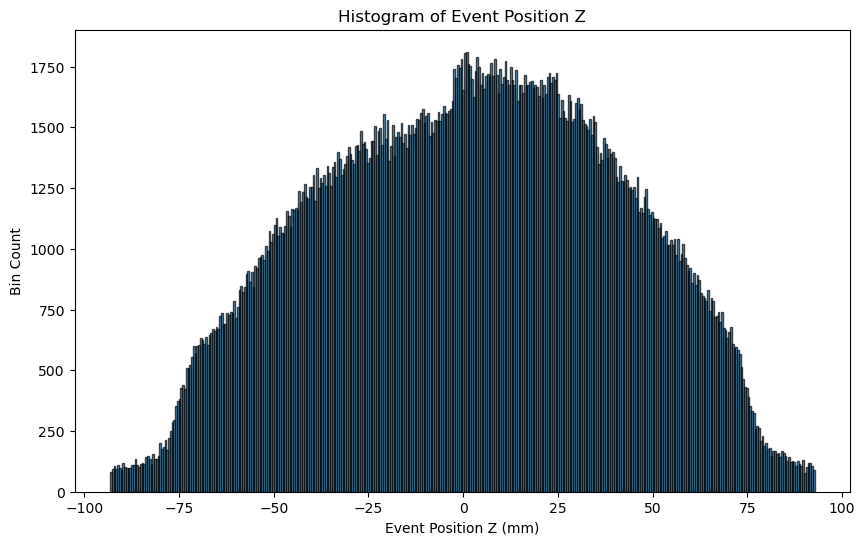

In [20]:
# Plot histogram of EventPosition_Z
hist_z, bins_z = np.histogram(df_filtered["EventPosition_Z"], bins=400)
plt.figure(figsize=(10, 6))
plt.bar(bins_z[:-1], hist_z, width=np.diff(bins_z), edgecolor="black", alpha=0.7)
plt.title("Histogram of Event Position Z")
plt.xlabel("Event Position Z (mm)")
plt.ylabel("Bin Count")

Text(0, 0.5, 'Event Position Y (mm)')

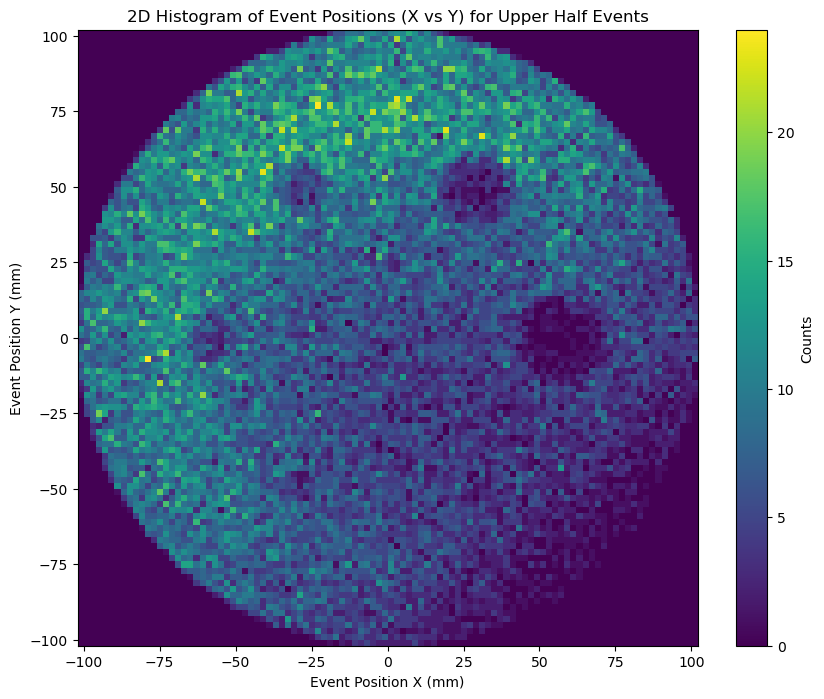

In [24]:
# filter the data again by Event_Position_Z
df_upper_half = df_filtered.filter(
    (df_filtered["EventPosition_Z"] > 30) & (df_filtered["EventPosition_Z"] < 50)
)
hist, xedges, yedges = np.histogram2d(
    df_upper_half["EventPosition_X"].to_numpy(),
    df_upper_half["EventPosition_Y"].to_numpy(),
    bins=102,
    range=[
        [-np.round(x_max, 0), np.round(x_max, 0)],
        [-np.round(y_max, 0), np.round(y_max, 0)],
    ],  # Adjust the range as needed based on your data
)
# Plot hist in 2d
plt.figure(figsize=(10, 8))
plt.imshow(
    hist.T,
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect="auto",
    cmap="viridis",
)
plt.colorbar(label="Counts")
plt.title("2D Histogram of Event Positions (X vs Y) for Upper Half Events")
plt.xlabel("Event Position X (mm)")
plt.ylabel("Event Position Y (mm)")


Text(0, 0.5, 'Event Position Y (mm)')

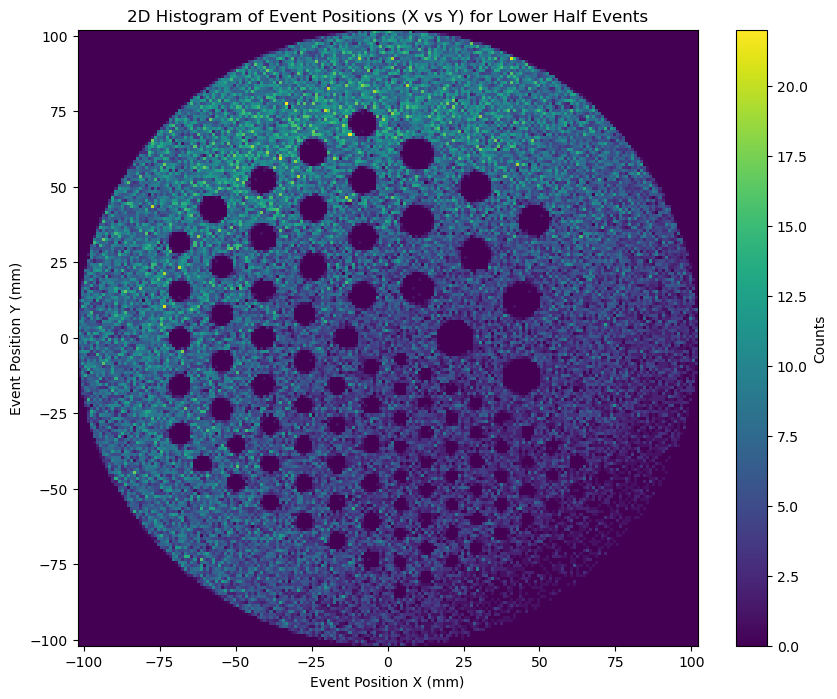

In [25]:
# filter the data again by Event_Position_Z
df_lower_half = df_filtered.filter(
    (df_filtered["EventPosition_Z"] > -100) & (df_filtered["EventPosition_Z"] < -10)
)
hist, xedges, yedges = np.histogram2d(
    df_lower_half["EventPosition_X"].to_numpy(),
    df_lower_half["EventPosition_Y"].to_numpy(),
    bins=204,
    range=[
        [-np.round(x_max, 0), np.round(x_max, 0)],
        [-np.round(y_max, 0), np.round(y_max, 0)],
    ],  # Adjust the range as needed based on your data
)
# Plot hist in 2d
plt.figure(figsize=(10, 8))
plt.imshow(
    hist.T,
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect="auto",
    cmap="viridis",
)
plt.colorbar(label="Counts")
plt.title("2D Histogram of Event Positions (X vs Y) for Lower Half Events")
plt.xlabel("Event Position X (mm)")
plt.ylabel("Event Position Y (mm)")

In [13]:
# Plot for all crystals, each with a 2D histogram of PixelID_X and PixelID_Y
unique_crystals = df_projection["CrystalID"].unique().to_list()
projection_data = np.empty((len(unique_crystals), 25, 25))
for crystal_id in unique_crystals:
    df_crystal = df_projection.filter(df_projection["CrystalID"] == crystal_id)
    hist_crystal, xedges_crystal, yedges_crystal = np.histogram2d(
        df_crystal["PixelID_X"].to_numpy(),
        df_crystal["PixelID_Y"].to_numpy(),
        bins=25,
        range=[
            [0, 25],
            [0, 25],
        ],  # PixelID_X and PixelID_Y should be in the range of 0 to 24, so we set the range to [0, 25] to include all possible values
    )
    projection_data[crystal_id - 1] = hist_crystal

In [ ]:
fig, axes = plt.subplots(
    nrows=4, ncols=20, sharex=True, sharey=True, figsize=(20, 4), dpi=200
)
for crystal_id in unique_crystals:
    # Plot hist in 2d for the current crystal
    ax = axes[(crystal_id - 1) % 4, (crystal_id - 1) // 4]
    im = ax.imshow(
        projection_data[crystal_id - 1].T,
        origin="lower",
        extent=[
            xedges_crystal[0],
            xedges_crystal[-1],
            yedges_crystal[0],
            yedges_crystal[-1],
        ],
        aspect="equal",
        cmap="viridis",
    )
    # ax.set_title(f'CrystalID={crystal_id}')
    if (crystal_id - 1) // 4 == 0:
        ax.set_ylabel("Y")
    if (crystal_id - 1) % 4 == 3:
        ax.set_xlabel("X")
    # ax.set_xlabel('Pixel Position X')
    # ax.set_ylabel('Pixel Position Y')
plt.tight_layout()

In [10]:
from mlem_sparse.io import SparseSRM_IO_Manager, MeasurementMat_IO_Manager
from mlem_sparse.reconstruct import SparseMLEMReconstructor
from pathlib import Path
# Load the system matrix
srm_io_mgr = SparseSRM_IO_Manager()

srm_scipy = srm_io_mgr.get_combined_srm()

Loading SRM heads:   0%|          | 0/80 [00:00<?, ?head/s]

In [11]:
import torch

In [74]:
# Let's check the srm_scipy to see the orientation and pixel mapping. 
# We can visualize the system matrix for a specific crystal to 
# understand how the pixels are mapped to the detector.
print(f"SRM shape: {srm_scipy.shape}")
srm_crystal_1 = srm_scipy.toarray().reshape(625, 100, 100, 100)  # Get the system matrix for the first crystal

SRM shape: (625, 1000000)


In [1]:
srm_crystal_array=[]
srm_npz_dir = Path("/data/shared/uamc-dcspect-srm-100/sparse_csr")
for crystal_id in range(1, 21):  # Assuming there are 80 crystals
    srm_crystal_scipy = srm_io_mgr.load_csr_from_npz(srm_npz_dir / f"uamc_head_{crystal_id}.npz")
    srm_crystal_array.append(srm_crystal_scipy.toarray().reshape(625, 100, 100, 100))  # Reshape to (625 pixels, 100x100x100 volume)

NameError: name 'Path' is not defined

In [18]:
from mlem_sparse.visualize import plot_volume_img_three_view

/tmp/ipykernel_926587/3857684578.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


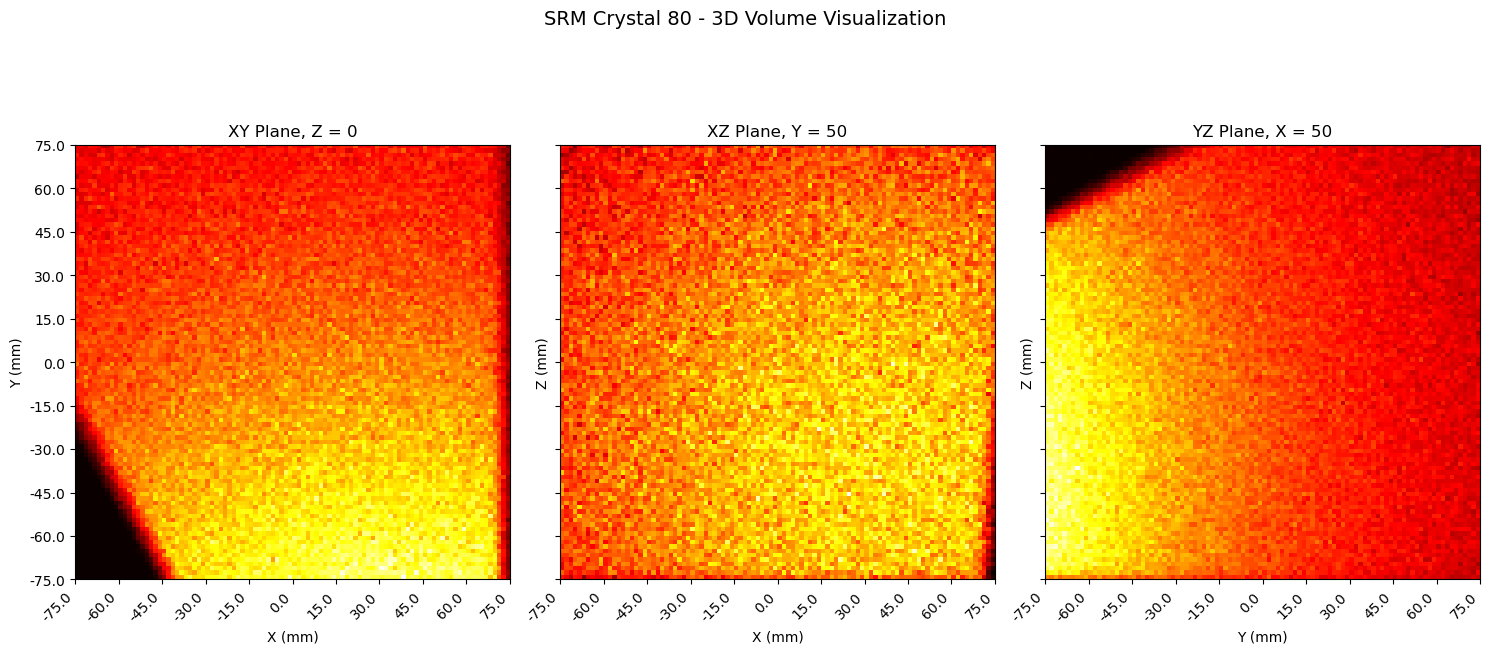

In [81]:
z_idx = 0
x_idx = 50
y_idx = 50
titles_dict = {
"xy view title": f"XY Plane, Z = {z_idx}",
"xz view title": f"XZ Plane, Y = {y_idx}",
"yz view title": f"YZ Plane, X = {x_idx}",
"figure suptitle": f"SRM Crystal {crystal_id} - 3D Volume Visualization",
}

fig, axes = plot_volume_img_three_view(
srm_crystal_1.sum(axis=0),  # Sum over the first axis (crystals) to get a 3D volume
z_slice_idx=z_idx,
y_slice_idx=y_idx,
x_slice_idx=x_idx,
img_vx_size_mm=(1.5,1.5,1.5),
titles_dict=titles_dict,
)
fig.tight_layout()
plt.show()

In [14]:
# print projection data shape
print("Projection data shape:", projection_data.shape)

Projection data shape: (80, 25, 25)


In [15]:
sparse_mlem_reconstructor_gpu = SparseMLEMReconstructor(
    srm_scipy,
    projection_data.flatten().astype(np.float32),
    device=torch.device("cuda"),
)

/home/fanghan/Work/RPIL/QMIRT/mc-srm-recon/mlem_sparse/src/mlem_sparse/reconstruct/sparse_mlem_reconstructor.py:156: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  self.srm_csr_tensor = torch.sparse_csr_tensor(
/home/fanghan/Work/RPIL/QMIRT/mc-srm-recon/mlem_sparse/src/mlem_sparse/reconstruct/sparse_mlem_reconstructor.py:156: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.srm_csr_tensor = torch.sparse_csr_tensor(


Skipping transpose computation to prevent OOM.
Requires ~7.00 GB (with safety margin).
But only 6.64 GB free on CUDA.
Backprojection will fallback to memory-conscious chunking.
Preparing chunked transpose on CPU system RAM...
Allocating permanent GPU streaming buffers...


In [16]:
iters = [1, 3, 5, 10, 20, 30, 40, 50, 70, 100, 200]
estimate_vol_sparse_mlem_tensor_from_gpu = sparse_mlem_reconstructor_gpu.reconstruct(
    iterations=iters
)
estimate_data_np_from_gpu = np.array(
    [
        gpu_tensor.detach().cpu().numpy()
        for gpu_tensor in estimate_vol_sparse_mlem_tensor_from_gpu
    ]
)
del estimate_vol_sparse_mlem_tensor_from_gpu

MLEM Iteration:   0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipykernel_941754/2499211154.py:24: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


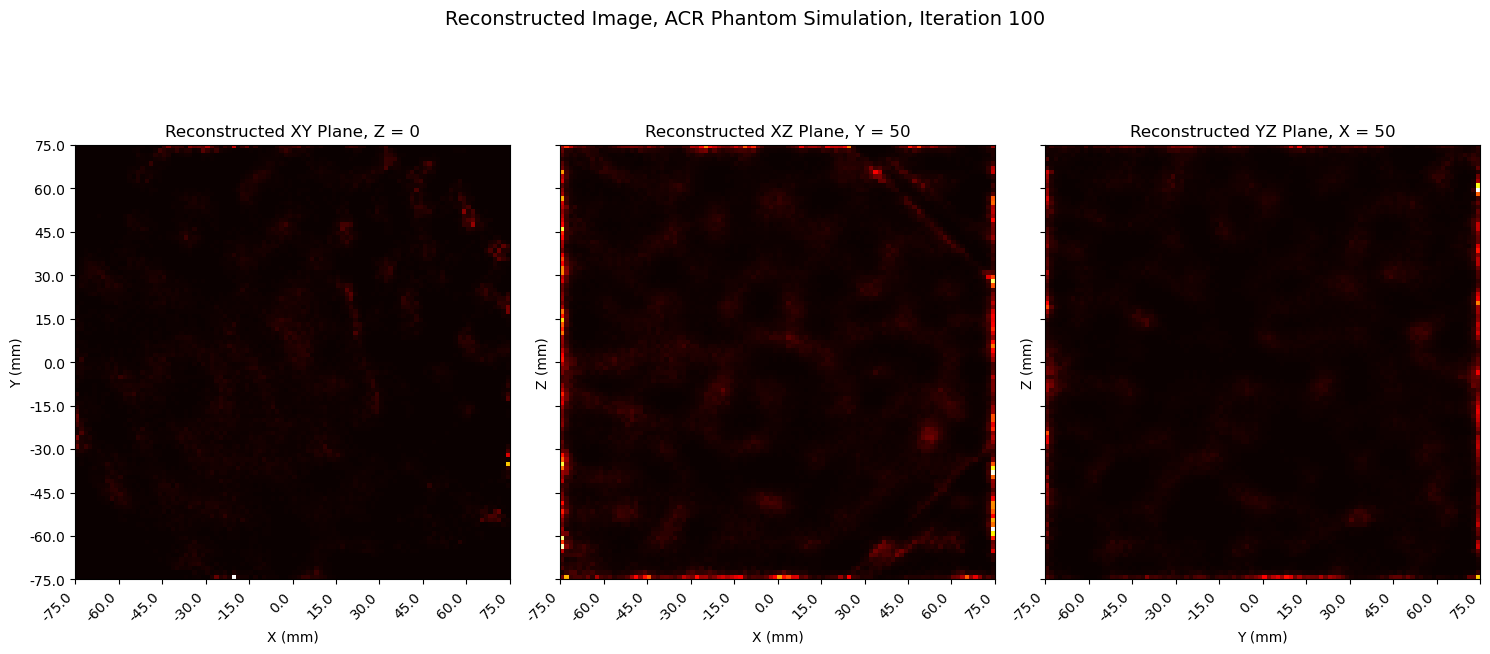

In [19]:
z_idx = 0
x_idx = 50
y_idx = 50
iter = 100
estimate_iter = estimate_data_np_from_gpu[iters.index(iter)]
img_shape = (100, 100, 100)
estimate_iter = estimate_iter.reshape(img_shape)
titles_dict = {
"xy view title": f"Reconstructed XY Plane, Z = {z_idx}",
"xz view title": f"Reconstructed XZ Plane, Y = {y_idx}",
"yz view title": f"Reconstructed YZ Plane, X = {x_idx}",
"figure suptitle": "Reconstructed Image, ACR Phantom Simulation, Iteration {:03d}".format(iter),
}


fig, axes = plot_volume_img_three_view(
estimate_iter,
z_slice_idx=z_idx,
y_slice_idx=y_idx,
x_slice_idx=x_idx,
img_vx_size_mm=(1.5,1.5,1.5),
titles_dict=titles_dict,
)
fig.tight_layout()
plt.show()